In [1]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [17]:
df = pd.read_csv("algerian3.csv")
df


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
240,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [21]:
feature_cols = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=feature_cols)

In [22]:
X = df[['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI']]
y = df['FWI']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [24]:
print(f"{X_train.shape[0]}")
X_test.shape[0]

194


49

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(X_train,y_train)

linear = LinearRegression().fit(X_train,y_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,X_train,y_train,"Baseline"),
    regresyon_raporu(linear,X_test,y_test,"Linear")
]).set_index("Model").round(3)
sonuc


,Mae,mse,rmse,r2
Model,,,,
Baseline,6.479,60.671,7.789,0.000
Linear,0.424,0.355,0.596,0.988


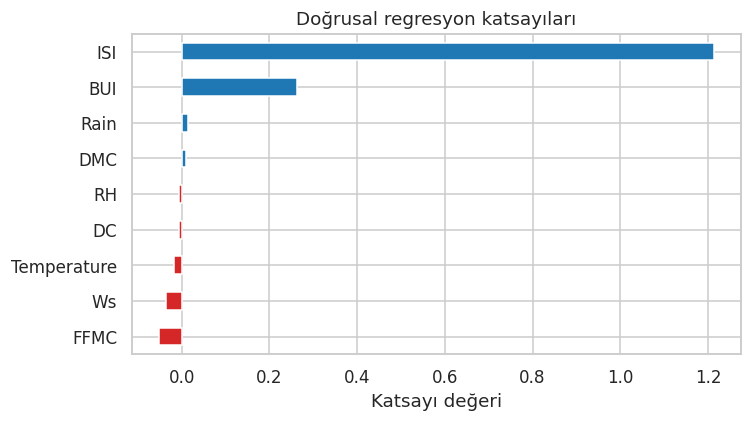

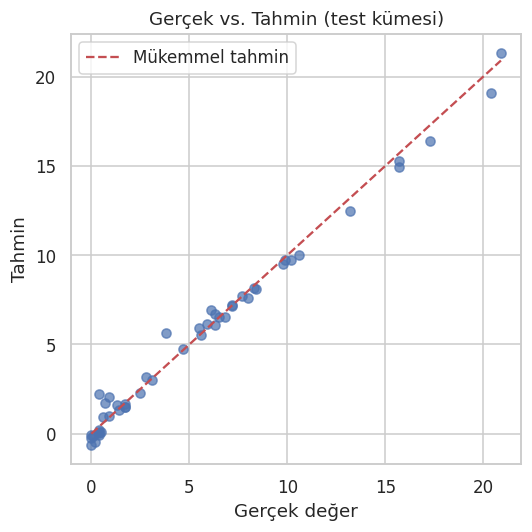

In [27]:
katsayilar = pd.Series(linear.coef_, index=X.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()


tahmin = linear.predict(X_test)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, tahmin, alpha=0.7)
lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller= {
    "Doğrusal": make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(),Lasso(alpha=1.0))
}

satirlar =[]

for ad,m in modeller.items():
  m.fit(X_train,y_train)
  satirlar.append(regresyon_raporu(m,X_test,y_test,ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,0.424,0.355,0.596,0.988
Ridge,0.477,0.565,0.751,0.981
Lasso,0.955,1.431,1.196,0.953


In [32]:
lasso= modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_,index=X.columns).round(2).to_frame("Lasso değişkenler").T

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI
Lasso değişkenler,0.0,-0.0,0.0,-0.0,0.0,1.65,0.0,4.12,1.43
